All final files loaded successfully.


,stage,users,conversion_from_previous,overall_conversion,conversion_from_previous_pct,overall_conversion_pct,dropoff_users,dropoff_rate_pct
0,Acquisition: Active grocery users,206209,1.000000,1.000000,100.000000,100.000000,0.0,0.000000
1,Activation: Bought 2+ organic items,181031,0.877901,0.877901,87.790058,87.790058,25178.0,12.209942
2,Retention: Bought organic in 3+ orders,166470,0.919566,0.807288,91.956626,80.728775,14561.0,8.043374
3,Loyalty: 15%+ organic basket share,136075,0.817415,0.659889,81.741455,65.988875,30395.0,18.258545
4,"High-value: 25%+ organic share, 5+ organic ord...",61585,0.452581,0.298653,45.258130,29.865331,74490.0,54.741870


,organic_segment,users,avg_total_orders,avg_total_items,avg_organic_items,avg_organic_orders,avg_organic_item_share,avg_organic_order_share,user_share_pct,growth_action
0,Organic loyal but not high-value,70664,9.434493,91.600150,27.761321,7.749618,0.352173,0.880628,34.268145,Upgrade to high-value using category expansion...
1,Organic high-value user,61585,27.597353,301.743412,132.603653,25.709994,0.431795,0.929440,29.865331,"Protect and monetize through membership, subsc..."
2,Organic low-share repeat user,34221,18.926595,191.448935,13.852021,8.578037,0.081536,0.528081,16.595299,Increase organic basket share using organic al...
3,Non-organic buyer,15643,8.719811,52.581986,0.000000,0.000000,0.000000,0.000000,7.585993,Drive first organic trial with starter offers ...
4,Organic early repeat user,14561,7.659776,56.214065,3.066067,1.832704,0.109820,0.342792,7.061282,Build habit through reorder nudges and small o...


,department,total_items,organic_items,users,organic_penetration_pct
0,beverages,550448,72705,55473,13.208332
1,household,125630,43,28567,0.034227
2,personal care,77330,4540,24785,5.870943
3,alcohol,19644,165,2865,0.839951
4,pets,13860,386,2913,2.784993


,product_name,users,orders,total_items,reorder_rate
0,Organic Fat-Free Milk,302,1692,1692,0.821513
1,Vitamin D Organic Milk,251,1346,1346,0.813522
2,Organic Low Fat Milk,709,3432,3432,0.793415
3,Organic 2% Reduced Fat Milk,1648,7036,7036,0.765776
4,Large Grade AA Organic Eggs,221,904,904,0.755531


Key funnel numbers extracted.
Main opportunity segment identified.
Top departments and products extracted.

Top cross-sell departments:
['beverages', 'household', 'personal care', 'alcohol', 'pets']

Top high-reorder organic products:
['Organic Fat-Free Milk', 'Vitamin D Organic Milk', 'Organic Low Fat Milk', 'Organic 2% Reduced Fat Milk', 'Large Grade AA Organic Eggs']


,experiment,target_segment,hypothesis,action,primary_metric,secondary_metric,impact,confidence,ease,ICE_score
0,Organic Replenishment Reminder,Users buying high-reorder organic products,Reminder nudges for frequently reordered organ...,Send reorder reminders for high-reorder organi...,Organic reorder rate,Organic orders per user,8,8,8,512
1,Organic Basket Expansion Recommendations,Organic loyal but not high-value users,Personalized organic recommendations will incr...,"Recommend organic alternatives in pantry, snac...",Organic item share,Organic departments per user,9,8,7,504
2,Organic Alternative Swap Campaign,Organic low-share repeat users,Suggesting organic alternatives to products us...,Show organic swap suggestions beside non-organ...,Organic penetration by department,Organic item share,7,7,7,343
3,Complete Your Organic Basket Bundle,Organic loyal but not high-value users,Bundling trusted organic categories with adjac...,Create weekly bundles like Organic Fresh + Dai...,Organic items per order,Average basket size,8,7,6,336
4,High-Value Organic Upgrade Offer,Organic loyal but not high-value users,A limited-time upgrade offer will convert loya...,Offer discount or reward when user crosses 25%...,Conversion to high-value organic user,Revenue proxy / basket share,9,6,5,270
5,Organic Membership / Subscription Pilot,Organic high-value users,A subscription/membership plan will increase r...,Offer recurring organic essentials pack or org...,Organic order frequency / retention,Repeat purchase rate,6,6,4,144


Growth experiment roadmap saved.


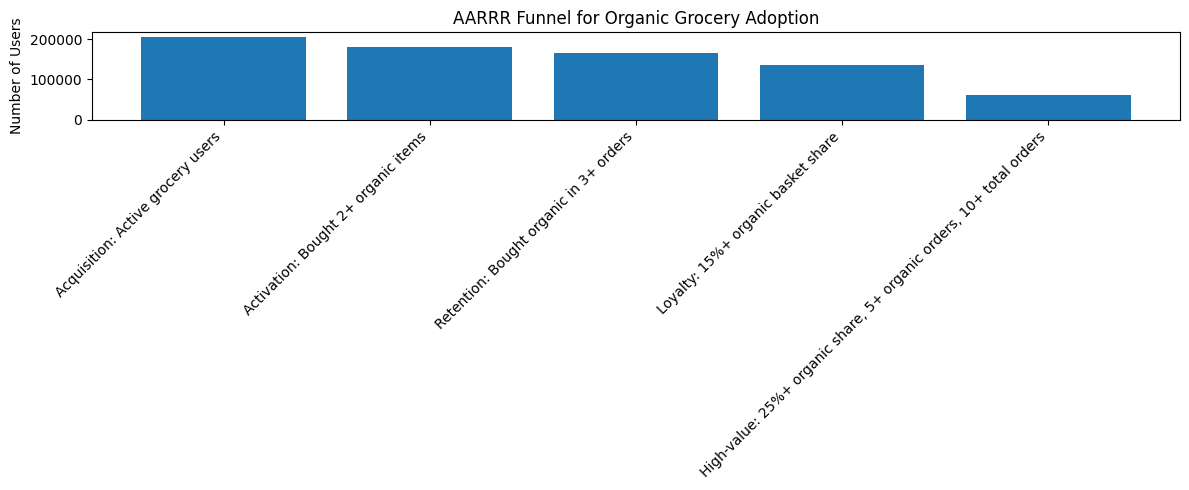

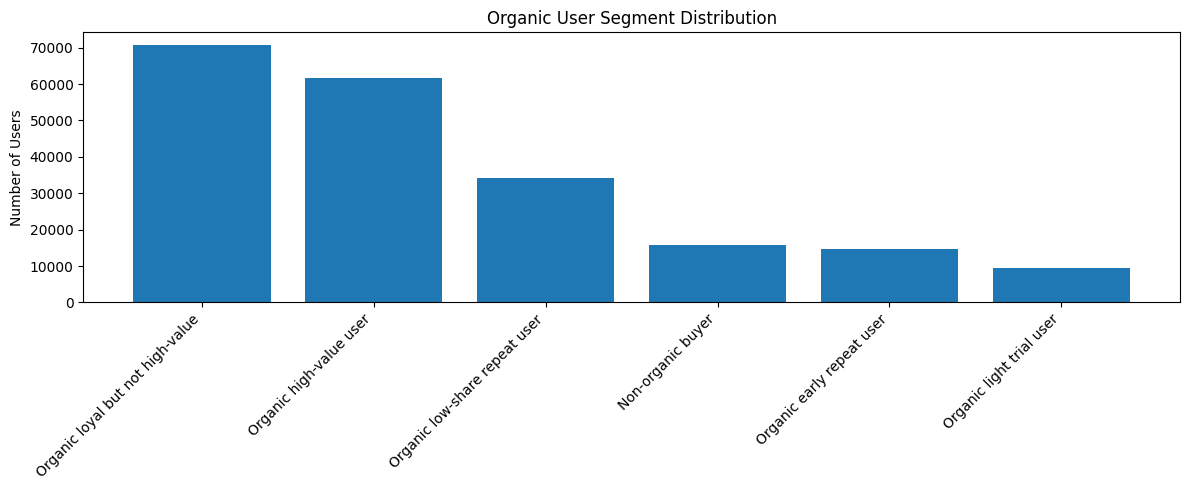

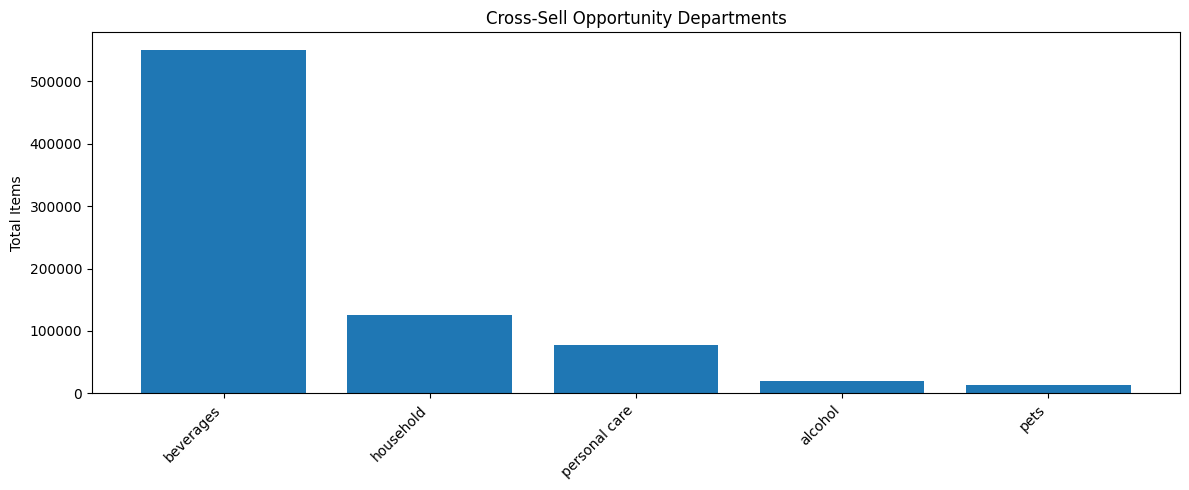

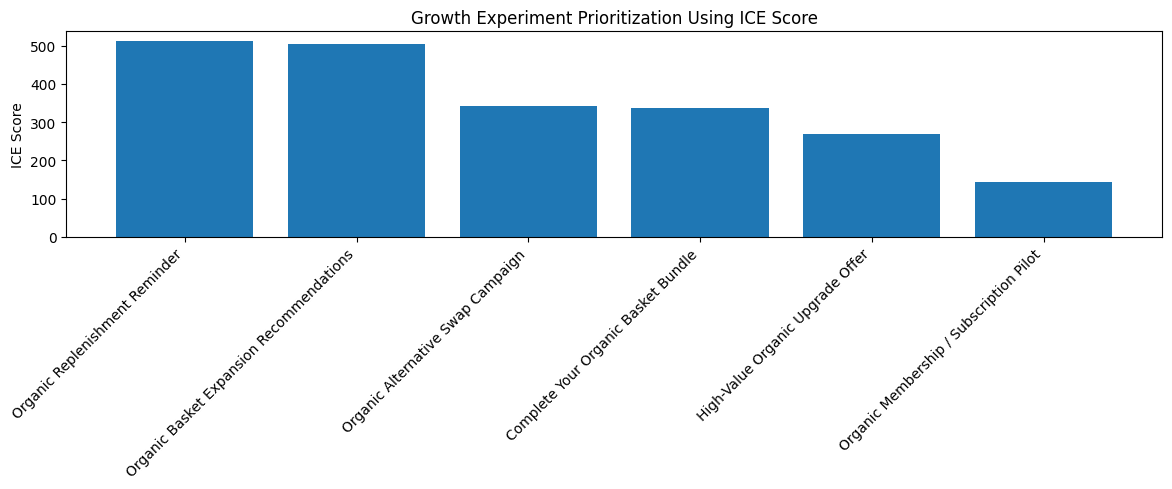

Charts saved in visuals folder.
Final report saved: reports/final_growth_report.md
Dashboard data pack saved: dashboard_data_pack.xlsx

Project completed successfully.


In [3]:
# ============================================================
# NOTEBOOK 5: Growth Strategy + Final Report
# File: 05_growth_strategy_final_report.ipynb
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

PROCESSED_PATH = "../data/processed/"
REPORT_PATH = "../reports/"
VISUAL_PATH = "../visuals/"

os.makedirs(REPORT_PATH, exist_ok=True)
os.makedirs(VISUAL_PATH, exist_ok=True)

# ============================================================
# STEP 1: Load all final processed outputs
# ============================================================

funnel = pd.read_csv(PROCESSED_PATH + "aarrr_organic_funnel.csv")
segment_summary = pd.read_csv(PROCESSED_PATH + "organic_segment_summary.csv")
department_penetration = pd.read_csv(PROCESSED_PATH + "department_organic_penetration.csv")
cross_sell_opportunity = pd.read_csv(PROCESSED_PATH + "cross_sell_opportunity_departments.csv")
high_reorder_products = pd.read_csv(PROCESSED_PATH + "high_reorder_organic_products.csv")
top_organic_products = pd.read_csv(PROCESSED_PATH + "top_organic_products_target_segment.csv")

print("All final files loaded successfully.")

display(funnel)
display(segment_summary.head())
display(cross_sell_opportunity.head())
display(high_reorder_products.head())

# ============================================================
# STEP 2: Clean department outputs
# ============================================================
# Logic:
# The dataset may contain a department called "missing".
# It is not useful for business recommendation, so we remove it.

department_penetration_clean = department_penetration[
    department_penetration["department"].str.lower() != "missing"
].copy()

cross_sell_opportunity_clean = cross_sell_opportunity[
    cross_sell_opportunity["department"].str.lower() != "missing"
].copy()

# Save cleaned files
department_penetration_clean.to_csv(
    PROCESSED_PATH + "department_organic_penetration_clean.csv",
    index=False
)

cross_sell_opportunity_clean.to_csv(
    PROCESSED_PATH + "cross_sell_opportunity_departments_clean.csv",
    index=False
)

# ============================================================
# STEP 3: Extract key numbers for final report
# ============================================================

total_users = int(funnel.loc[0, "users"])
activation_users = int(funnel.loc[1, "users"])
retention_users = int(funnel.loc[2, "users"])
loyal_users = int(funnel.loc[3, "users"])
high_value_users = int(funnel.loc[4, "users"])

activation_rate = float(funnel.loc[1, "overall_conversion_pct"])
retention_rate = float(funnel.loc[2, "overall_conversion_pct"])
loyal_rate = float(funnel.loc[3, "overall_conversion_pct"])
high_value_rate = float(funnel.loc[4, "overall_conversion_pct"])

biggest_dropoff_stage = funnel.sort_values("dropoff_users", ascending=False).iloc[0]
biggest_dropoff_users = int(biggest_dropoff_stage["dropoff_users"])
biggest_dropoff_rate = float(biggest_dropoff_stage["dropoff_rate_pct"])
biggest_dropoff_name = biggest_dropoff_stage["stage"]

print("Key funnel numbers extracted.")

# ============================================================
# STEP 4: Identify main opportunity segment
# ============================================================

main_segment_name = "Organic loyal but not high-value"

main_segment = segment_summary[
    segment_summary["organic_segment"] == main_segment_name
]

if not main_segment.empty:
    main_segment_users = int(main_segment["users"].iloc[0])
    main_segment_share = float(main_segment["user_share_pct"].iloc[0])
    main_segment_avg_orders = float(main_segment["avg_total_orders"].iloc[0])
    main_segment_avg_organic_items = float(main_segment["avg_organic_items"].iloc[0])
    main_segment_avg_organic_share = float(main_segment["avg_organic_item_share"].iloc[0]) * 100
else:
    main_segment_users = None
    main_segment_share = None
    main_segment_avg_orders = None
    main_segment_avg_organic_items = None
    main_segment_avg_organic_share = None

print("Main opportunity segment identified.")

# ============================================================
# STEP 5: Identify top opportunity departments
# ============================================================

top_cross_sell_departments = cross_sell_opportunity_clean.head(5)["department"].tolist()

top_organic_departments = (
    department_penetration_clean
    .sort_values("organic_penetration_pct", ascending=False)
    .head(5)["department"]
    .tolist()
)

top_reorder_products = (
    high_reorder_products
    .sort_values("reorder_rate", ascending=False)
    .head(5)["product_name"]
    .tolist()
)

top_products_by_volume = (
    top_organic_products
    .sort_values("total_items", ascending=False)
    .head(5)["product_name"]
    .tolist()
)

print("Top departments and products extracted.")

print("\nTop cross-sell departments:")
print(top_cross_sell_departments)

print("\nTop high-reorder organic products:")
print(top_reorder_products)

# ============================================================
# STEP 6: Create Growth Experiment Roadmap
# ============================================================
# Logic:
# Each experiment has:
# - target segment
# - hypothesis
# - action
# - primary metric
# - ICE score
#
# ICE = Impact × Confidence × Ease

experiments = pd.DataFrame({
    "experiment": [
        "Organic Basket Expansion Recommendations",
        "Complete Your Organic Basket Bundle",
        "Organic Replenishment Reminder",
        "Organic Alternative Swap Campaign",
        "High-Value Organic Upgrade Offer",
        "Organic Membership / Subscription Pilot"
    ],
    
    "target_segment": [
        "Organic loyal but not high-value users",
        "Organic loyal but not high-value users",
        "Users buying high-reorder organic products",
        "Organic low-share repeat users",
        "Organic loyal but not high-value users",
        "Organic high-value users"
    ],
    
    "hypothesis": [
        "Personalized organic recommendations will increase organic item share among warm users.",
        "Bundling trusted organic categories with adjacent categories will increase organic basket depth.",
        "Reminder nudges for frequently reordered organic products will increase repeat organic orders.",
        "Suggesting organic alternatives to products users already buy will increase organic penetration in low-share categories.",
        "A limited-time upgrade offer will convert loyal users into high-value organic buyers.",
        "A subscription/membership plan will increase retention and monetize already high-value users."
    ],
    
    "action": [
        "Recommend organic alternatives in pantry, snacks, frozen, beverages, and bakery.",
        "Create weekly bundles like Organic Fresh + Dairy + Pantry Basket.",
        "Send reorder reminders for high-reorder organic products.",
        "Show organic swap suggestions beside non-organic products.",
        "Offer discount or reward when user crosses 25% organic basket share.",
        "Offer recurring organic essentials pack or organic membership benefits."
    ],
    
    "primary_metric": [
        "Organic item share",
        "Organic items per order",
        "Organic reorder rate",
        "Organic penetration by department",
        "Conversion to high-value organic user",
        "Organic order frequency / retention"
    ],
    
    "secondary_metric": [
        "Organic departments per user",
        "Average basket size",
        "Organic orders per user",
        "Organic item share",
        "Revenue proxy / basket share",
        "Repeat purchase rate"
    ],
    
    "impact": [9, 8, 8, 7, 9, 6],
    "confidence": [8, 7, 8, 7, 6, 6],
    "ease": [7, 6, 8, 7, 5, 4]
})

experiments["ICE_score"] = (
    experiments["impact"] *
    experiments["confidence"] *
    experiments["ease"]
)

experiments = experiments.sort_values(
    by="ICE_score",
    ascending=False
).reset_index(drop=True)

display(experiments)

experiments.to_csv(
    PROCESSED_PATH + "growth_experiment_roadmap.csv",
    index=False
)

print("Growth experiment roadmap saved.")

# ============================================================
# STEP 7: Create final charts for report
# ============================================================

# Funnel chart
plt.figure(figsize=(12, 5))
plt.bar(funnel["stage"], funnel["users"])
plt.xticks(rotation=45, ha="right")
plt.title("AARRR Funnel for Organic Grocery Adoption")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.savefig(VISUAL_PATH + "aarrr_funnel.png", dpi=200)
plt.show()

# Segment chart
plt.figure(figsize=(12, 5))
plt.bar(segment_summary["organic_segment"], segment_summary["users"])
plt.xticks(rotation=45, ha="right")
plt.title("Organic User Segment Distribution")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.savefig(VISUAL_PATH + "organic_user_segments.png", dpi=200)
plt.show()

# Cross-sell department chart
cross_sell_chart = cross_sell_opportunity_clean.head(10)

plt.figure(figsize=(12, 5))
plt.bar(cross_sell_chart["department"], cross_sell_chart["total_items"])
plt.xticks(rotation=45, ha="right")
plt.title("Cross-Sell Opportunity Departments")
plt.ylabel("Total Items")
plt.tight_layout()
plt.savefig(VISUAL_PATH + "cross_sell_departments.png", dpi=200)
plt.show()

# Experiment ICE chart
plt.figure(figsize=(12, 5))
plt.bar(experiments["experiment"], experiments["ICE_score"])
plt.xticks(rotation=45, ha="right")
plt.title("Growth Experiment Prioritization Using ICE Score")
plt.ylabel("ICE Score")
plt.tight_layout()
plt.savefig(VISUAL_PATH + "growth_experiment_ice.png", dpi=200)
plt.show()

print("Charts saved in visuals folder.")

# ============================================================
# STEP 8: Create final business report in Markdown
# ============================================================

top_cross_sell_text = ", ".join(top_cross_sell_departments)
top_reorder_text = ", ".join(top_reorder_products)
top_volume_text = ", ".join(top_products_by_volume)

final_report = f"""
# Organic Grocery Growth Engine

## 1. Project Objective

This project analyzes organic product adoption using online grocery order data.  
The goal is to understand how users move from trying organic products to becoming high-value organic buyers, and to design growth experiments that increase organic basket share and repeat organic purchasing.

---

## 2. Dataset Overview

The project uses grocery order data containing:

- Users
- Orders
- Products
- Aisles
- Departments
- Reorder behavior

The raw data was transformed into a user-level growth analytics dataset by tagging organic products and creating user-level metrics such as organic item share, organic order frequency, and organic segment.

---

## 3. Methodology

The project followed this workflow:

1. Loaded raw grocery order and product data
2. Merged products with aisle and department information
3. Combined prior and train order-product data
4. Created a master transaction table
5. Tagged organic products using product names
6. Built user-level organic behavior metrics
7. Created an AARRR-style funnel
8. Segmented users by organic behavior
9. Analyzed product and department opportunities
10. Designed ICE-prioritized growth experiments

---

## 4. AARRR Funnel Findings

The stricter organic adoption funnel was defined as:

| Stage | Definition |
|---|---|
| Acquisition | User has at least 1 grocery order |
| Activation | User bought 2+ organic items |
| Retention | User bought organic in 3+ orders |
| Loyalty | Organic items are 15%+ of basket |
| High-value | 25%+ organic share, 5+ organic orders, 10+ total orders |

### Funnel Results

| Stage | Users | Overall Conversion |
|---|---:|---:|
| Active grocery users | {total_users:,} | 100.00% |
| Bought 2+ organic items | {activation_users:,} | {activation_rate:.2f}% |
| Bought organic in 3+ orders | {retention_users:,} | {retention_rate:.2f}% |
| 15%+ organic basket share | {loyal_users:,} | {loyal_rate:.2f}% |
| High-value organic users | {high_value_users:,} | {high_value_rate:.2f}% |

### Key Funnel Insight

The largest leakage occurs before the high-value stage.  
The biggest drop-off is at:

**{biggest_dropoff_name}**

This stage loses **{biggest_dropoff_users:,} users**, with a drop-off rate of **{biggest_dropoff_rate:.2f}%**.

This indicates that the primary growth challenge is not first-time organic trial.  
Many users are already buying organic products. The real opportunity is converting loyal organic buyers into high-value organic buyers.

---

## 5. User Segmentation Findings

Users were segmented based on:

- Organic item count
- Organic order count
- Organic basket share
- High-value qualification

The most important growth opportunity is:

**Organic loyal but not high-value users**

This segment contains users who already show meaningful organic buying behavior but have not yet reached high-value organic status.

"""

if main_segment_users is not None:
    final_report += f"""
### Main Opportunity Segment

| Metric | Value |
|---|---:|
| Users | {main_segment_users:,} |
| User Share | {main_segment_share:.2f}% |
| Avg Total Orders | {main_segment_avg_orders:.2f} |
| Avg Organic Items | {main_segment_avg_organic_items:.2f} |
| Avg Organic Item Share | {main_segment_avg_organic_share:.2f}% |

This segment is attractive because these users are already warm.  
They have organic buying behavior, but need basket expansion, category cross-sell, and stronger habit formation to become high-value users.
"""

final_report += f"""

---

## 6. Product and Category Insights

Product/category analysis focused on the loyal-but-not-high-value segment.

### Key Findings

Top organic products by volume include:

**{top_volume_text}**

High-reorder organic products include:

**{top_reorder_text}**

Top cross-sell opportunity departments include:

**{top_cross_sell_text}**

The analysis shows that organic behavior is concentrated in trusted categories such as produce and dairy/eggs.  
However, growth opportunities exist in adjacent categories where users already buy products but organic penetration is lower.

---

## 7. Growth Strategy

The strategy should shift from:

> Make users try organic

to:

> Make organic a larger part of the user's grocery basket

The recommended strategy is to use trusted organic categories as anchors and expand users into adjacent organic categories.

### Strategic Pillars

1. **Organic Basket Expansion**  
   Recommend organic alternatives in low-penetration categories.

2. **Category Cross-Sell**  
   Move users from organic produce/dairy into organic pantry, snacks, frozen, beverages, and bakery.

3. **Replenishment Nudges**  
   Use high-reorder organic products for reminder and subscription campaigns.

4. **High-Value Upgrade Campaign**  
   Target loyal users close to 25% organic basket share with incentives and bundles.

---

## 8. Growth Experiment Roadmap

The experiments were prioritized using ICE scoring:

ICE = Impact × Confidence × Ease

| Experiment | Target Segment | Primary Metric | ICE Score |
|---|---|---|---:|
"""

for _, row in experiments.iterrows():
    final_report += f"| {row['experiment']} | {row['target_segment']} | {row['primary_metric']} | {int(row['ICE_score'])} |\n"

final_report += """

---

## 9. Final Recommendation

The core opportunity is to convert loyal organic buyers into high-value organic buyers.

The first experiment should be:

**Organic Basket Expansion Recommendations**

This experiment targets loyal-but-not-high-value users with personalized organic alternatives in categories they already buy.  
The goal is to increase organic item share from the 15–24% range to 25%+, thereby moving users into the high-value organic segment.

---

## 10. Portfolio Summary

This project demonstrates:

- Product analytics thinking
- AARRR funnel design
- User segmentation
- Behavioral metric engineering
- Organic product adoption analysis
- Growth experiment design
- Business recommendation development

The project converts raw transaction data into a clear Growth PM strategy.

"""

with open(REPORT_PATH + "final_growth_report.md", "w", encoding="utf-8") as f:
    f.write(final_report)

print("Final report saved: reports/final_growth_report.md")


# ============================================================
# STEP 9: Create dashboard data pack
# ============================================================

with pd.ExcelWriter(PROCESSED_PATH + "dashboard_data_pack.xlsx") as writer:
    funnel.to_excel(writer, sheet_name="AARRR Funnel", index=False)
    segment_summary.to_excel(writer, sheet_name="User Segments", index=False)
    department_penetration_clean.to_excel(writer, sheet_name="Dept Penetration", index=False)
    cross_sell_opportunity_clean.to_excel(writer, sheet_name="Cross Sell", index=False)
    high_reorder_products.to_excel(writer, sheet_name="High Reorder Products", index=False)
    experiments.to_excel(writer, sheet_name="Experiments", index=False)

print("Dashboard data pack saved: dashboard_data_pack.xlsx")

print("\nProject completed successfully.")